=== target vs baseline (in %) ===
FOMC ret_next      n= 125  mean=-0.079%  std=1.529%  min=-5.76%  max=+9.06%
all-day ret        n=4120  mean=+0.059%  std=1.079%  min=-10.94%  max=+10.50%

volatility ratio (FOMC ret_next std / all-day std) = 1.42
  >1 means FOMC days move SPY more than average  -> event has bite
  ~1 means FOMC day looks like any other day      -> weak premise



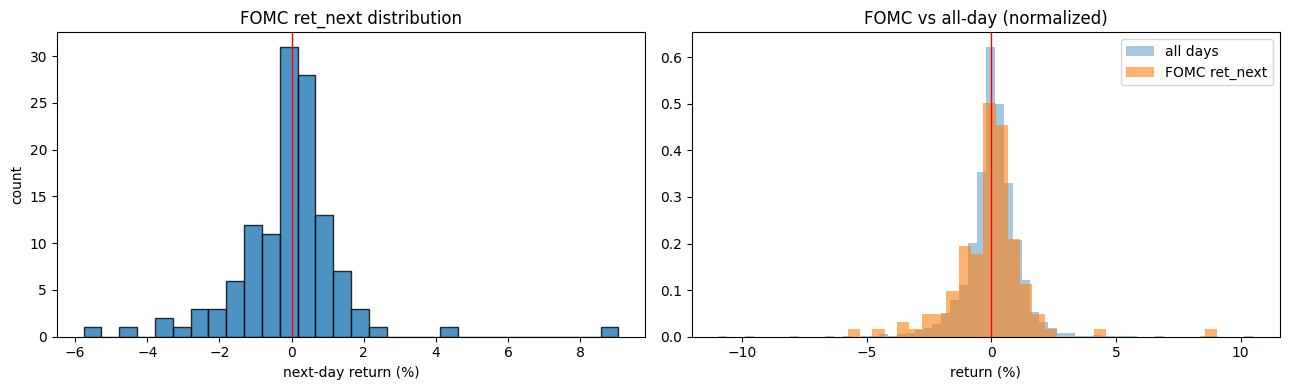

=== top 8 absolute ret_next moves (the events that will dominate any correlation) ===
      date  ret_next_pct  sentiment
2020-03-23          9.06   0.120585
2020-06-10         -5.76   0.734268
2011-08-09         -4.42  -0.087466
2020-03-03          4.20  -0.291436
2022-05-04         -3.55  -0.255171
2022-06-15         -3.31  -0.143935
2011-09-21         -3.23   0.383518
2018-03-21         -2.50   0.328502


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FOMC-day merged data (the 125 event rows)
fomc = pd.read_csv("../data/processed/fomc_spy.csv")
fomc["date"] = pd.to_datetime(fomc["date"]).dt.normalize()
fomc = fomc.dropna(subset=["ret_next"]).sort_values("date").reset_index(drop=True)

# full SPY series for the baseline comparison (is FOMC day special?)
spy = pd.read_csv("../data/processed/spy_daily.csv")
spy.columns = spy.columns.str.lower()             # mixed-case "Date" gotcha
spy["date"] = pd.to_datetime(spy["date"]).dt.normalize()
spy = spy.sort_values("date").reset_index(drop=True)

# --- 1. summary stats: FOMC ret_next vs all-day ret ---
def describe(s, label):
    print(f"{label:18s} n={s.notna().sum():4d}  mean={s.mean()*100:+.3f}%  "
          f"std={s.std()*100:.3f}%  min={s.min()*100:+.2f}%  max={s.max()*100:+.2f}%")

print("=== target vs baseline (in %) ===")
describe(fomc["ret_next"], "FOMC ret_next")     # day AFTER each FOMC
describe(spy["ret"],       "all-day ret")        # every trading day, baseline
print()

# variance ratio: is the day after FOMC more volatile than a random day?
vr = fomc["ret_next"].std() / spy["ret"].std()
print(f"volatility ratio (FOMC ret_next std / all-day std) = {vr:.2f}")
print("  >1 means FOMC days move SPY more than average  -> event has bite")
print("  ~1 means FOMC day looks like any other day      -> weak premise")
print()

# --- 2. distribution shape ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(fomc["ret_next"]*100, bins=30, edgecolor="black", alpha=0.8)
ax[0].axvline(0, color="red", lw=1)
ax[0].set_title("FOMC ret_next distribution")
ax[0].set_xlabel("next-day return (%)"); ax[0].set_ylabel("count")

# overlay FOMC vs all-day densities, normalized, to compare spread
ax[1].hist(spy["ret"].dropna()*100, bins=60, density=True, alpha=0.4, label="all days")
ax[1].hist(fomc["ret_next"]*100,    bins=30, density=True, alpha=0.6, label="FOMC ret_next")
ax[1].axvline(0, color="red", lw=1)
ax[1].set_title("FOMC vs all-day (normalized)")
ax[1].set_xlabel("return (%)"); ax[1].legend()
plt.tight_layout(); plt.show()

# --- 3. who are the outliers? (biggest absolute next-day moves) ---
print("=== top 8 absolute ret_next moves (the events that will dominate any correlation) ===")
top = fomc.reindex(fomc["ret_next"].abs().sort_values(ascending=False).index).head(8)
print(top[["date", "ret_next", "sentiment"]].assign(
        ret_next_pct=lambda d: (d["ret_next"]*100).round(2)
      )[["date", "ret_next_pct", "sentiment"]].to_string(index=False))

=== sentiment vs target ===
sentiment ~ ret_next     n=125  Pearson r=-0.082 (p=0.36)  Spearman rho=-0.057 (p=0.53)
sentiment ~ ret          n=125  Pearson r=+0.037 (p=0.68)  Spearman rho=+0.018 (p=0.84)

=== same, with top-8 |ret_next| outliers removed ===
sentiment ~ ret_next     n=117  Pearson r=-0.065 (p=0.49)  Spearman rho=-0.062 (p=0.51)
sentiment ~ ret          n=117  Pearson r=+0.114 (p=0.22)  Spearman rho=+0.083 (p=0.37)



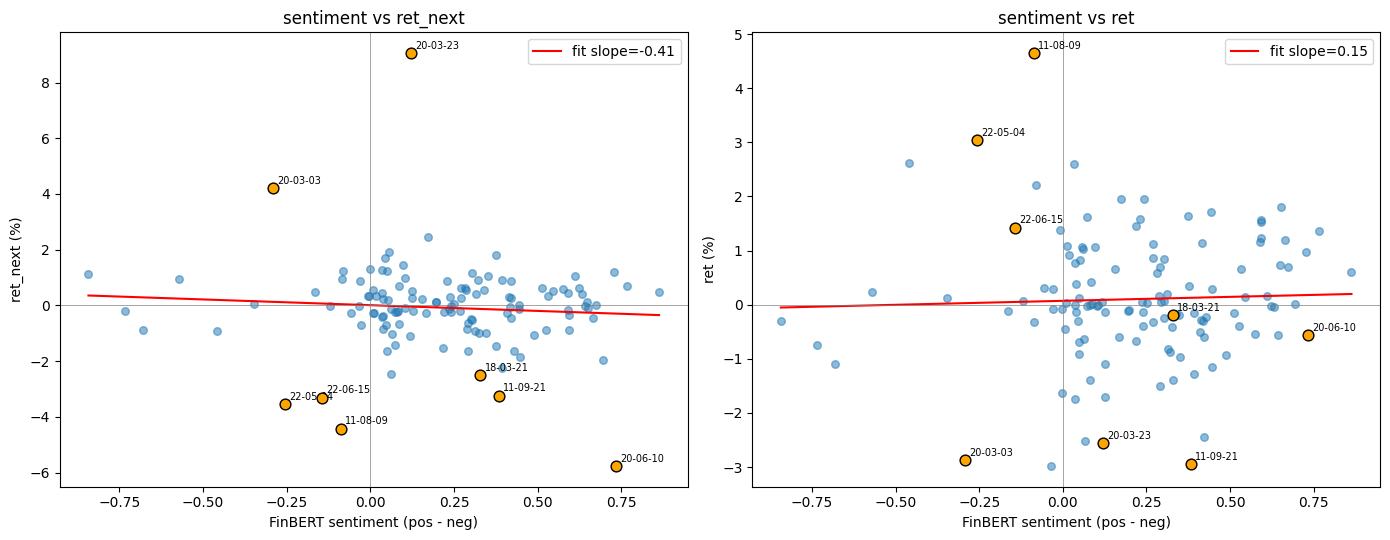

In [2]:
# sentiment vs SPY correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fomc = pd.read_csv("../data/processed/fomc_spy.csv")
fomc["date"] = pd.to_datetime(fomc["date"]).dt.normalize()
fomc = fomc.dropna(subset=["ret_next"]).sort_values("date").reset_index(drop=True)

# the 8 outliers we just inspected — label these on the plot
outlier_dates = pd.to_datetime([
    "2020-03-23","2020-06-10","2011-08-09","2020-03-03",
    "2022-05-04","2022-06-15","2011-09-21","2018-03-21"
])

# --- correlations: both targets, Pearson + Spearman ---
def corr_report(x, y, label):
    m = x.notna() & y.notna()
    x, y = x[m], y[m]
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)   # rank-based, robust to outliers
    print(f"{label:24s} n={len(x):3d}  Pearson r={pr:+.3f} (p={pp:.2f})  "
          f"Spearman rho={sr:+.3f} (p={sp:.2f})")

print("=== sentiment vs target ===")
corr_report(fomc["sentiment"], fomc["ret_next"], "sentiment ~ ret_next")
corr_report(fomc["sentiment"], fomc["ret"],      "sentiment ~ ret")
print()

# robustness: drop the 8 biggest-|ret_next| events, recompute
mask_no_out = ~fomc["date"].isin(outlier_dates)
print("=== same, with top-8 |ret_next| outliers removed ===")
corr_report(fomc.loc[mask_no_out,"sentiment"], fomc.loc[mask_no_out,"ret_next"], "sentiment ~ ret_next")
corr_report(fomc.loc[mask_no_out,"sentiment"], fomc.loc[mask_no_out,"ret"],      "sentiment ~ ret")
print()

# --- scatter with regression line + outlier labels ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for i, tgt in enumerate(["ret_next", "ret"]):
    a = ax[i]
    a.scatter(fomc["sentiment"], fomc[tgt]*100, alpha=0.5, s=30)
    # regression line over full sample
    m = fomc["sentiment"].notna() & fomc[tgt].notna()
    b1, b0 = np.polyfit(fomc.loc[m,"sentiment"], fomc.loc[m,tgt]*100, 1)
    xs = np.linspace(fomc["sentiment"].min(), fomc["sentiment"].max(), 50)
    a.plot(xs, b1*xs+b0, color="red", lw=1.5, label=f"fit slope={b1:.2f}")
    # label the 8 outliers
    out = fomc[fomc["date"].isin(outlier_dates)]
    a.scatter(out["sentiment"], out[tgt]*100, color="orange", s=60, zorder=5, edgecolor="black")
    for _, r in out.iterrows():
        a.annotate(r["date"].strftime("%y-%m-%d"),
                   (r["sentiment"], r[tgt]*100),
                   fontsize=7, xytext=(3,3), textcoords="offset points")
    a.axhline(0, color="gray", lw=0.5); a.axvline(0, color="gray", lw=0.5)
    a.set_xlabel("FinBERT sentiment (pos - neg)")
    a.set_ylabel(f"{tgt} (%)")
    a.set_title(f"sentiment vs {tgt}")
    a.legend()
plt.tight_layout(); plt.show()

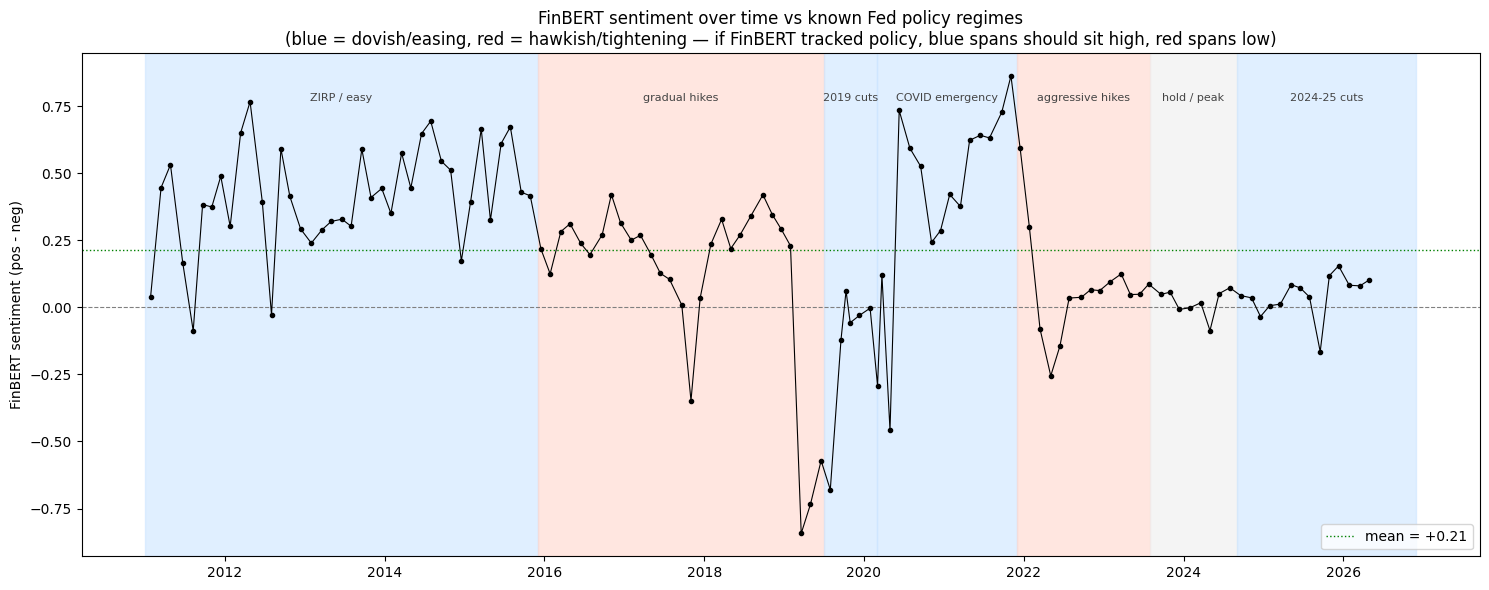

=== mean FinBERT sentiment by ACTUAL policy stance ===
          mean  count
stance               
dovish   0.297     74
hawkish  0.106     43
neutral  0.019      8

if FinBERT tracked policy: dovish mean >> hawkish mean
if axis is mismatched     : means are similar, or even backwards


In [ ]:
fomc = pd.read_csv("../data/processed/fomc_spy.csv")
fomc["date"] = pd.to_datetime(fomc["date"]).dt.normalize()
fomc = fomc.dropna(subset=["sentiment"]).sort_values("date").reset_index(drop=True)

# regimes defined from EXTERNAL knowledge (actual Fed actions), NOT from the sentiment data
# (hardcoding avoids circular logic: outside truth first, then check if FinBERT matches)
regimes = [
    ("2011-01-01", "2015-12-01", "ZIRP / easy",      "dovish",  "#cce5ff"),
    ("2015-12-01", "2019-07-01", "gradual hikes",     "hawkish", "#ffd6cc"),
    ("2019-07-01", "2020-03-01", "2019 cuts",         "dovish",  "#cce5ff"),
    ("2020-03-01", "2021-12-01", "COVID emergency",   "dovish",  "#cce5ff"),
    ("2021-12-01", "2023-08-01", "aggressive hikes",  "hawkish", "#ffd6cc"),
    ("2023-08-01", "2024-09-01", "hold / peak",       "neutral", "#eeeeee"),
    ("2024-09-01", "2026-12-01", "2024-25 cuts",      "dovish",  "#cce5ff"),
]

fig, ax = plt.subplots(figsize=(15, 6))

# shade each regime; blue = dovish (market-friendly), red = hawkish
for start, end, label, stance, color in regimes:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    ax.axvspan(s, e, color=color, alpha=0.6, zorder=0)
    mid = s + (e - s) / 2
    ax.text(mid, 0.92, label, ha="center", va="top", fontsize=8,
            transform=ax.get_xaxis_transform(), color="#444")

# sentiment time series
ax.plot(fomc["date"], fomc["sentiment"], marker="o", ms=3, lw=0.8,
        color="black", zorder=3)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(fomc["sentiment"].mean(), color="green", lw=1, ls=":",
           label=f"mean = {fomc['sentiment'].mean():+.2f}")

ax.set_ylabel("FinBERT sentiment (pos - neg)")
ax.set_title("FinBERT sentiment over time vs known Fed policy regimes\n"
             "(blue = dovish/easing, red = hawkish/tightening — if FinBERT tracked policy, "
             "blue spans should sit high, red spans low)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

# quantify: mean sentiment per stance — does dovish actually score higher than hawkish?
print("=== mean FinBERT sentiment by ACTUAL policy stance ===")
def stance_of(d):
    for start, end, label, stance, color in regimes:
        if pd.Timestamp(start) <= d < pd.Timestamp(end):
            return stance
    return "unknown"
fomc["stance"] = fomc["date"].apply(stance_of)
print(fomc.groupby("stance")["sentiment"].agg(["mean", "count"]).round(3))
print()
print("if FinBERT tracked policy: dovish mean >> hawkish mean")
print("if axis is mismatched     : means are similar, or even backwards")